<a href="https://colab.research.google.com/github/yunseo449/ESAA/blob/main/YB_1009(2)_%E1%84%8B%E1%85%A7%E1%86%AB%E1%84%89%E1%85%B3%E1%86%B8%E1%84%86%E1%85%AE%E1%86%AB%E1%84%8C%E1%85%A6_%E1%84%91%E1%85%A7%E1%86%BC%E1%84%80%E1%85%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
print(cm)

[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [4]:
# 정확도 : 전체 예측 중에서 모델이 실제값과 일치하게 맞춘 비율
from sklearn.metrics import accuracy_score

acc= accuracy_score(y, y_pred)
print(f"정확도: {acc:.4f}")

# 모델이 음성(1)과 양성(0)을 전체적으로 얼마나 정확하게 분류했는지 직관적으로 파악할 수 있다.

정확도: 0.9121


**정밀도의 개념을 설명하고, 정밀도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [5]:
# 정밀도 : 모델이 음성(1)이라고 예측한 것들 중에서 실제로 진짜 음성(1)인 것의 비율
from sklearn.metrics import precision_score

prec = precision_score(y, y_pred)
print(f"정밀도: {prec:.4f}")

#모델이 양성(0)을 음성(1)으로 잘못 판정하는 오류를 얼마나 줄였는지 알 수 있다.

정밀도: 0.9010


**재현율의 개념을 설명하고, 재현율을 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [6]:
# 재현율 : 실제 진짜 음성(1) 데이터 중에서 모델이 음성(1)이라고 정확히 맞춘 비율
from sklearn.metrics import recall_score

rec = recall_score(y, y_pred)
print(f"재현율: {rec:.4f}")

# 실제 음성 환자를 양성으로 놓치는 오류를 얼마나 방지했는지 알 수 있다.

재현율: 0.8585


**F1 score의 개념을 설명하고, F1 score를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [7]:
# F1 score : 정밀도와 재현율의 조화평균
from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)
print(f"F1 score: {f1:.4f}")

# 정밀도와 재현율 중 어느 한쪽으로 치우치지 않고 두 지표가 균형을 이루고 있는지 통합 평가할 수 있다.

F1 score: 0.8792


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [8]:
from sklearn.preprocessing import Binarizer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 예측 확률 구하기 (pred_proba)
# pred_proba[:, 0]: 0(양성)일 확률, pred_proba[:, 1]: 1(음성)일 확률
pred_proba = model_lor.predict_proba(X)

# Binarizer를 사용하여 0으로 예측할 확률이 0.1 초과인 경우 0, 이하인 경우 1 지정
# 0일 확률이 0.1보다 크다 -> (1 - 0일 확률)인 1일 확률은 0.9 미만이라는 의미
# threshold=0.9로 설정하면 1일 확률이 0.9보다 클 때만 1(음성)로 분류
binarizer = Binarizer(threshold=0.9)
y_pred2 = binarizer.fit_transform(pred_proba[:, 1].reshape(-1, 1))

In [9]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
print("혼동행렬:\n", confusion_matrix(y, y_pred2))
print("정확도:", accuracy_score(y, y_pred2))
print("정밀도:", precision_score(y, y_pred2))
print("재현율:", recall_score(y, y_pred2))
print("F1 score:", f1_score(y, y_pred2))

혼동행렬:
 [[356   1]
 [ 73 139]]
정확도: 0.8699472759226714
정밀도: 0.9928571428571429
재현율: 0.6556603773584906
F1 score: 0.7897727272727273


**ROC 곡선 시각화**

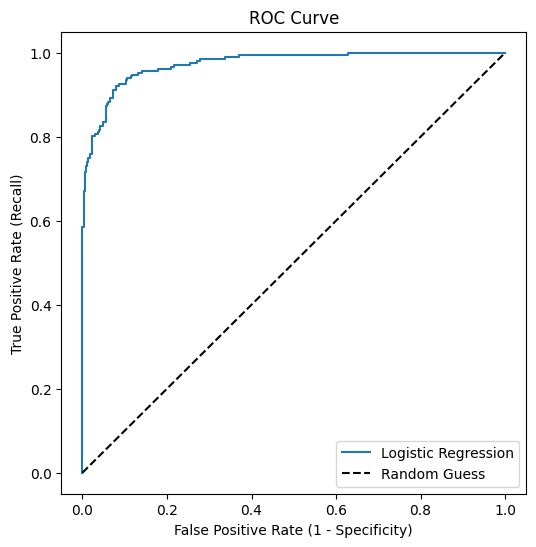

In [10]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# 1(음성)일 확률 추출
pred_proba_class1 = pred_proba[:, 1]

# fpr, tpr, thresholds 계산
fpr, tpr, thresholds = roc_curve(y, pred_proba_class1)

# ROC 곡선 그리기
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # 기준선 (AUC = 0.5)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [11]:
from sklearn.metrics import roc_auc_score

# ROC AUC 계산
roc_auc = roc_auc_score(y, pred_proba[:, 1])
print(f"ROC AUC 값: {roc_auc:.4f}")

ROC AUC 값: 0.9741


ROC AUC 값이 0.9741이라는 것은 모델이 임계값 변화와 관계없이 음성과 양성 데이터 클래스를 구별해내는 분류 성능이 매우 뛰어남을 의미한다.